Предыдущий код - нужен для дальнейших работ

In [125]:
# Импорт необходимых библиотек
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns

In [126]:
# Генерация искусственного датасета
def generate_braking_data(n_samples=100, noise_level=10, random_state=42):
    """
    Генерирует данные с нормальным шумом (физически корректные).
    """
    np.random.seed(random_state)

    # Генерируем скорости от 1 до 30 м/с (108 км/ч)
    v = np.linspace(1, 30, n_samples)

    # Физическая зависимость: s = v²/(2a), где a ≈ 4 м/с²
    s_ideal = v**2 / (2 * 4)

    # Добавляем нормальный шум
    noise = np.random.normal(0, noise_level, n_samples)
    s = s_ideal + noise

    # убираем отрицательные тормозные пути
    s = np.maximum(s, 0.1)  # Все значения меньше 0.1 становятся 0.1

    return v, s

In [127]:
# Создаем dataset
v, s = generate_braking_data(n_samples=500)

In [128]:
# Добавляем фиктивный признак x₀ = 1
X = np.column_stack([np.ones(len(v)), v])  # X = [1, v]

In [129]:
# Реализация функций

def compute_predictions(X, theta):
    """Вычисление предсказаний: Xθ"""
    return X @ theta

def compute_loss(X, y, theta):
    """Функция потерь MSE: L(θ) = 1/(2n) * Σ(y_i - x_iθ)²"""
    n = len(y)
    errors = y - compute_predictions(X, theta)
    return (1 / (2 * n)) * np.sum(errors ** 2)

def compute_gradient(X, y, theta):
    """Градиент: ∇L(θ) = (1/n) * Xᵀ(Xθ - y)"""
    n = len(y)
    predictions = compute_predictions(X, theta)
    errors = predictions - y
    return (1 / n) * X.T @ errors

In [130]:
# Проверим работу функций на нулевых начальных параметрах
theta_init = np.array([0.0, 0.0]) #Т.е. получается у нас тупо прямая y = 0
# loss_init = compute_loss(X, s, theta_init)
# gradient_init = compute_gradient(X, s, theta_init)

In [131]:
def gradient_descent(X, y, initial_theta, learning_rate=0.001, n_iterations=100):
    """Реализация градиентного спуска"""
    theta = initial_theta.copy()
    loss_history = []

    for i in range(n_iterations):
        # Вычисляем градиент
        gradient = compute_gradient(X, y, theta)

        # Обновляем параметры
        theta = theta - learning_rate * gradient

        # Сохраняем значение функции потерь
        loss = compute_loss(X, y, theta)
        loss_history.append(loss)

    return theta, loss_history

# Задание: Изучение работы градиентного спуска и улучшение модели

##  1: Исследование шага обучения
Проведите эксперименты с разными значениями шага обучения (η). Попробуйте (это примерные значения):
- Очень маленькие: 0.00001, 0.0001
- Умеренные: 0.001, 0.005  
- Слишком большие: 0.01, 0.1

Для каждого η:
1. Запустите градиентный спуск на 100 итераций (или другое число)
2. Постройте график функции потерь
3. Найдите случаи: медленная сходимость, хорошая сходимость, расходимость


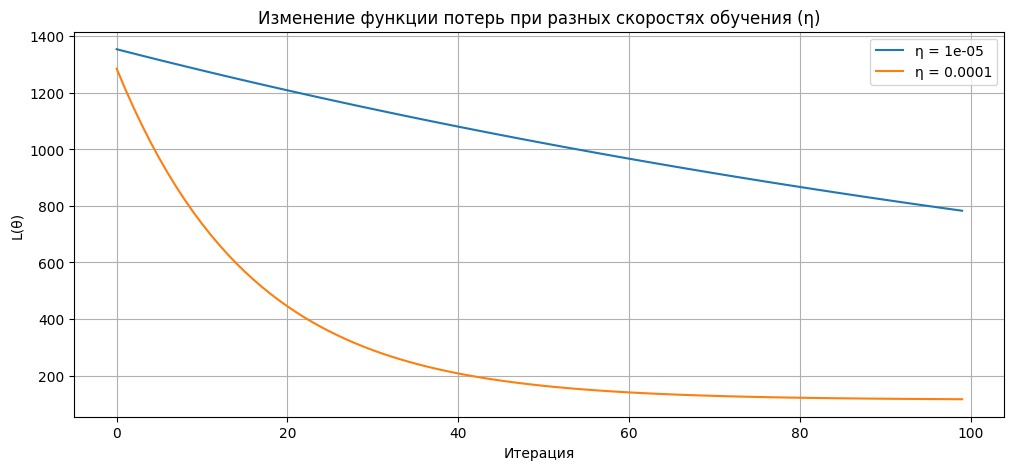

η = 1e-05
  → θ₀ = 0.034, θ₁ = 0.757
  → Конечная ошибка: L(θ) = 782.3879

η = 0.0001
  → θ₀ = 0.092, θ₁ = 2.709
  → Конечная ошибка: L(θ) = 116.2001



In [132]:
#Рассмотрим при Очень маленькие: 0.00001, 0.0001
etas = [0.00001, 0.0001]
results = {}

for eta in etas:
    theta_opt, loss_hist = gradient_descent(X, s, theta_init, learning_rate=eta, n_iterations=100)
    results[eta] = (theta_opt, loss_hist)

# === Визуализация ===
plt.figure(figsize=(12, 5))

for eta, (_, loss_hist) in results.items():
    plt.plot(loss_hist, label=f"η = {eta}")

plt.title("Изменение функции потерь при разных скоростях обучения (η)")
plt.xlabel("Итерация")
plt.ylabel("L(θ)")
plt.legend()
plt.grid(True)
plt.show()

# === Пояснение ===
for eta, (theta, loss) in results.items():
    print(f"η = {eta}")
    print(f"  → θ₀ = {theta[0]:.3f}, θ₁ = {theta[1]:.3f}")
    print(f"  → Конечная ошибка: L(θ) = {loss[-1]:.4f}\n")



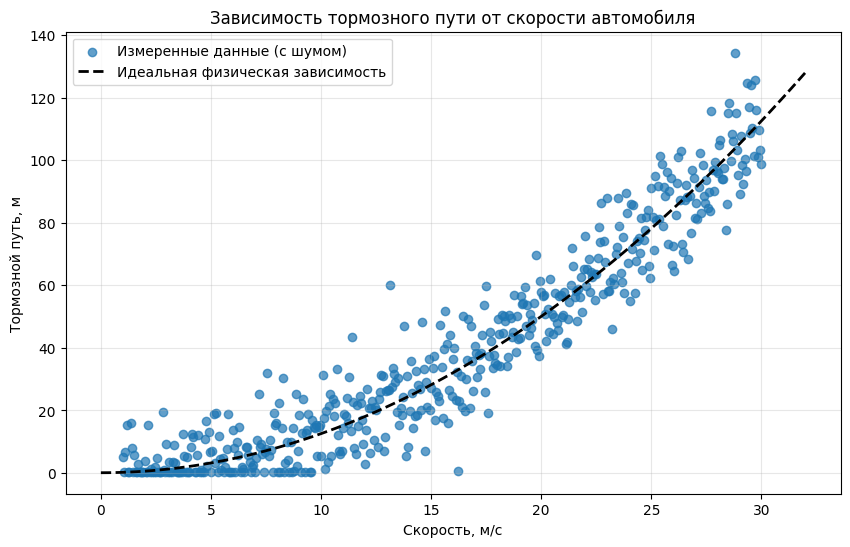

In [133]:
# Визуализация сгенерированных данных
plt.figure(figsize=(10, 6))
plt.scatter(v, s, alpha=0.7, label='Измеренные данные (с шумом)')

v_ideal = np.linspace(0, 32, 100) #Увеличение графика
s_ideal = v_ideal**2 / (2 * 4.0)
plt.plot(v_ideal, s_ideal, 'k--', linewidth=2, label='Идеальная физическая зависимость')

plt.xlabel('Скорость, м/с')
plt.ylabel('Тормозной путь, м')
plt.title('Зависимость тормозного пути от скорости автомобиля')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

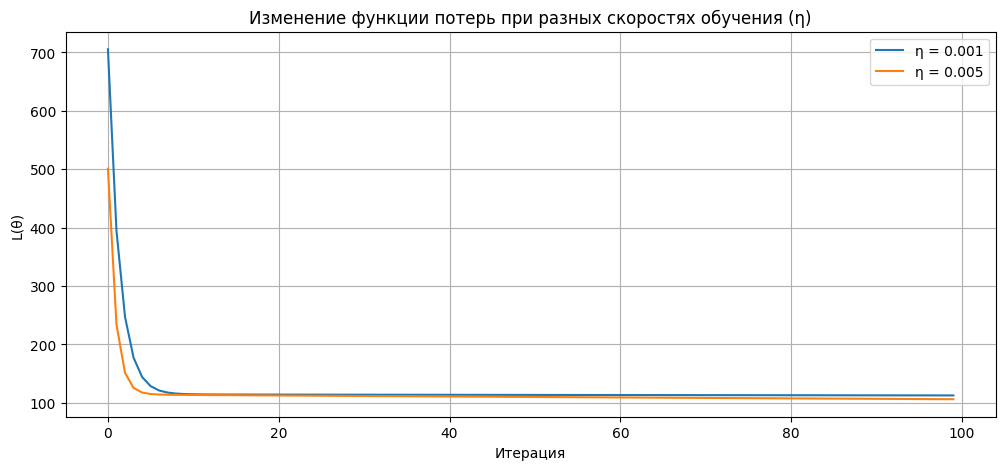

η = 0.001
  → θ₀ = -0.285, θ₁ = 2.848
  → Конечная ошибка: L(θ) = 112.3389

η = 0.005
  → θ₀ = -1.896, θ₁ = 2.928
  → Конечная ошибка: L(θ) = 105.8343



In [134]:
#Рассмотрим при Умеренные: 0.001, 0.005
etas = [0.001, 0.005]
results = {}

for eta in etas:
    theta_opt, loss_hist = gradient_descent(X, s, theta_init, learning_rate=eta, n_iterations=100)
    results[eta] = (theta_opt, loss_hist)

# === Визуализация ===
plt.figure(figsize=(12, 5))

for eta, (_, loss_hist) in results.items():
    plt.plot(loss_hist, label=f"η = {eta}")

plt.title("Изменение функции потерь при разных скоростях обучения (η)")
plt.xlabel("Итерация")
plt.ylabel("L(θ)")
plt.legend()
plt.grid(True)
plt.show()

# === Пояснение ===
for eta, (theta, loss) in results.items():
    print(f"η = {eta}")
    print(f"  → θ₀ = {theta[0]:.3f}, θ₁ = {theta[1]:.3f}")
    print(f"  → Конечная ошибка: L(θ) = {loss[-1]:.4f}\n")

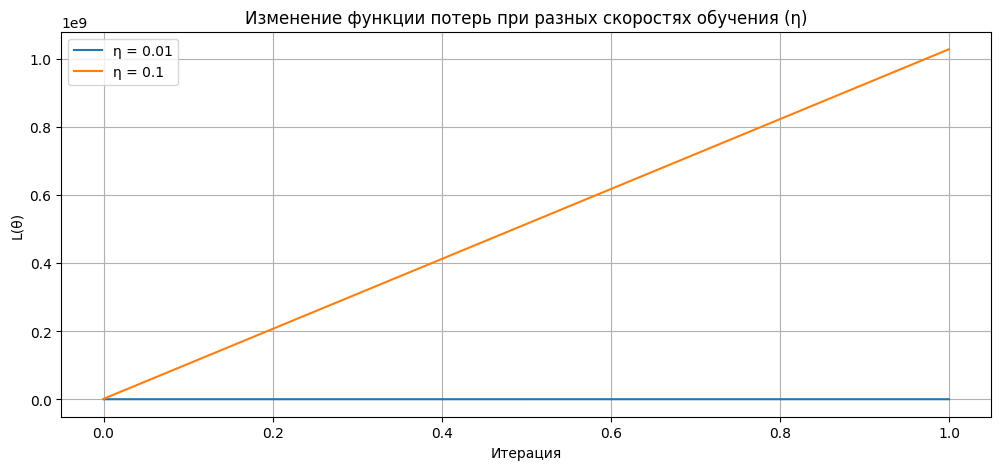

η = 0.01
  → θ₀ = -0.576, θ₁ = -9.799
  → Конечная ошибка: L(θ) = 25011.1224

η = 0.1
  → θ₀ = -128.919, θ₁ = -2564.513
  → Конечная ошибка: L(θ) = 1028809125.1273



In [135]:
#Рассмотрим при Большие: 0.01, 0.1
etas = [0.01, 0.1]
results = {}

for eta in etas:
    theta_opt, loss_hist = gradient_descent(X, s, theta_init, learning_rate=eta, n_iterations=2)
    results[eta] = (theta_opt, loss_hist)

# === Визуализация ===
plt.figure(figsize=(12, 5))

for eta, (_, loss_hist) in results.items():
    plt.plot(loss_hist, label=f"η = {eta}")

plt.title("Изменение функции потерь при разных скоростях обучения (η)")
plt.xlabel("Итерация")
plt.ylabel("L(θ)")
plt.legend()
plt.grid(True)
plt.show()

# === Пояснение ===
for eta, (theta, loss) in results.items():
    print(f"η = {eta}")
    print(f"  → θ₀ = {theta[0]:.3f}, θ₁ = {theta[1]:.3f}")
    print(f"  → Конечная ошибка: L(θ) = {loss[-1]:.4f}\n")

##  2: Оценка качества модели
Для лучшей линейной модели вычислите метрики качества:
- MSE, MAE, MAPE, R²
- Используйте функции из sklearn.metrics

In [136]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

v = v.reshape(-1, 1) #Создаем двумерный массив
model = LinearRegression()
model.fit(v, s)

# Получаем предсказания
y_pred = model.predict(v)

# Вычисляем все метрики:
r2 = r2_score(s, y_pred)                    # R² - коэффициент детерминации
mae = mean_absolute_error(s, y_pred)        # MAE - средняя абсолютная ошибка
mse = mean_squared_error(s, y_pred)         # MSE - средняя квадратичная ошибка  
rmse = np.sqrt(mse)                              # RMSE - корень из MSE
mape = mean_absolute_percentage_error(s, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print("MAPE:", mape)

MAE: 9.6297
MSE: 146.0627
RMSE: 12.0856
R²: 0.8730
MAPE: 10.513215979791582


## 3: Квадратичная модель
Улучшите модель, добавив квадратичный признак:
1. Создайте признаки: [1, v, v²]
2. Обучите модель с 3 параметрами
3. Постройте кривую обучения
4. Вычислите метрики и сравните с линейной моделью
5. Сделайте выводы: какая модель лучше и почему

ValueError: X has 2 features, but LinearRegression is expecting 3 features as input.

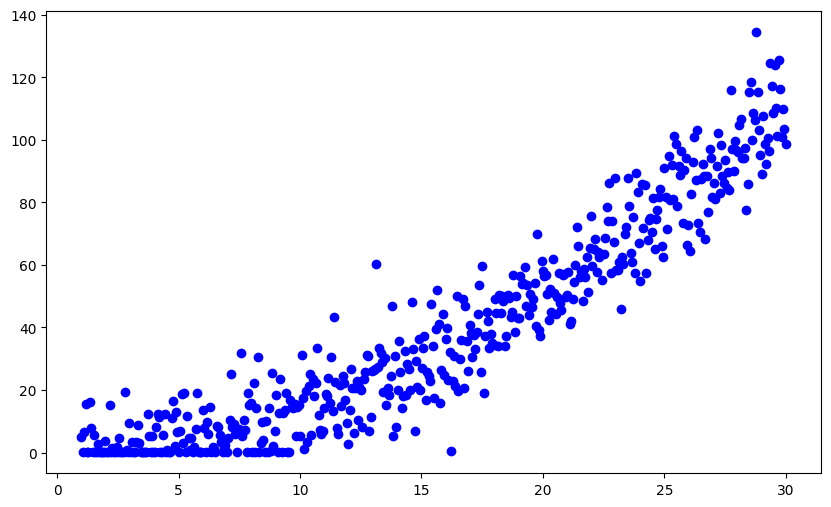

In [137]:
#Создание признаков
v2 = v**2
duo_X = np.column_stack([np.ones(len(v)), v, v2])

model = LinearRegression()
model.fit(duo_X, s)
# Предсказания
y_pred_quad = model.predict(duo_X)

plt.figure(figsize=(10,6))
plt.scatter(v, s, color='blue', label='Исходные данные')

# Для красивой линии — сортируем точки по v
v_range = np.linspace(v.min(), v.max(), 200).reshape(-1, 1)
v2_range = v_range ** 2
X_range_quad = np.hstack([v_range, v2_range])
y_range_pred = model.predict(X_range_quad)

plt.plot(v_range, y_range_pred, color='red', label='Квадратичная модель')
plt.xlabel('Скорость, м/с')
plt.ylabel('Тормозной путь, м')
plt.legend()
plt.title('Квадратичная регрессия')
plt.grid(True, alpha = 0.3)
plt.show()


In [ ]:
mse_quad = mean_squared_error(s, y_pred_quad)
mae_quad = mean_absolute_error(s, y_pred_quad)
mape_quad = mean_absolute_percentage_error(s, y_pred_quad)
r2_quad = r2_score(s, y_pred_quad)
rmse_quad = np.sqrt(mse_quad)

print(f"MAE (Quad):  {mae_quad:.4f}")
print(f"MSE (Quad):  {mse_quad:.4f}")
print(f"RMSE (Quad): {rmse_quad:.4f}")
print(f"R² (Quad):   {r2_quad:.4f}")
print(f"MAPE (Quad): {mape_quad:.4f}")

MAE (Quad):  7.0858
MSE (Quad):  82.7357
RMSE (Quad): 9.0959
R² (Quad):   0.9281
MAPE (Quad): 6.5051


In [ ]:
## Результаты:
###Метрики   Линейная   Квадратичная
MAE           9.6297      7.0858
MSE           146.0627    82.7357
RMSE          12.0856     9.0959
R²            0.8730      0.9281
MAPE          10.513      6.5051